In [1]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from shapely.geometry import Point
import pandas as pd
from plotnine import *
from geopandas import GeoDataFrame
import contextily as cx

%matplotlib inline

In [2]:
# converting to points 
df = pd.read_csv("cleaned_harris_snap_data.csv")

# Create point geometries
geometry = gpd.points_from_xy(df["Longitude"], df["Latitude"])

geo_df = gpd.GeoDataFrame(
    df[["Store_Name", "Store_Street_Address", "City", "Zip_Code", "Store_Type", "Latitude", "Longitude"]], 
    geometry=geometry,
    crs="EPSG:4326"
)

geo_df.head()

,Store_Name,Store_Street_Address,City,Zip_Code,Store_Type,Latitude,Longitude,geometry
0,Joe V's Smart Shop 792,4107 Fry RD.,Katy,77449,Supermarket,29.832573,-95.722534,POINT (-95.72253 29.83257)
1,Siempre Grocery 019,9922 S Gessner Rd,Houston,77071,Grocery Store,29.670755,-95.528809,POINT (-95.52881 29.67076)
2,HEB Food Store 759,19529 Northpark Dr,Kingwood,77339,Supermarket,30.068659,-95.251701,POINT (-95.2517 30.06866)
3,Cypress Grocery And Halal Meat,11700 Barker Cypress Rd,Houston,77433,Grocery Store,29.945112,-95.676521,POINT (-95.67652 29.94511)
4,Kohinoor Indo/pak Grocery Halal Meat & Cafe,20423 Kuykendahl Rd,Spring,77379,Grocery Store,30.067778,-95.507751,POINT (-95.50775 30.06778)


In [3]:
# dallas= gpd.read_file("tl_2025_48_tract.shp")
harris = gpd.read_file("../Census_Tract/tl_2025_48_tract.shp")

(1115, 14)


<Axes: >

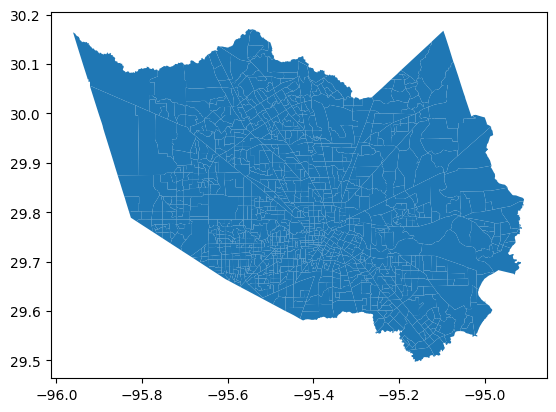

In [4]:
# filter for county
harris = harris[harris["COUNTYFP"] == "201"]

print(harris.shape)
harris.plot()

In [5]:
print("harris CRS:", harris.crs)
print("geo_df CRS:", geo_df.crs)

harris CRS: EPSG:4269
geo_df CRS: EPSG:4326


In [6]:
# convert my data to Web Mercator because it matches the mapping data we are using from contexitly
harris_wm = harris.to_crs(epsg=3857)
geo_df_wm = geo_df.to_crs(epsg=3857)

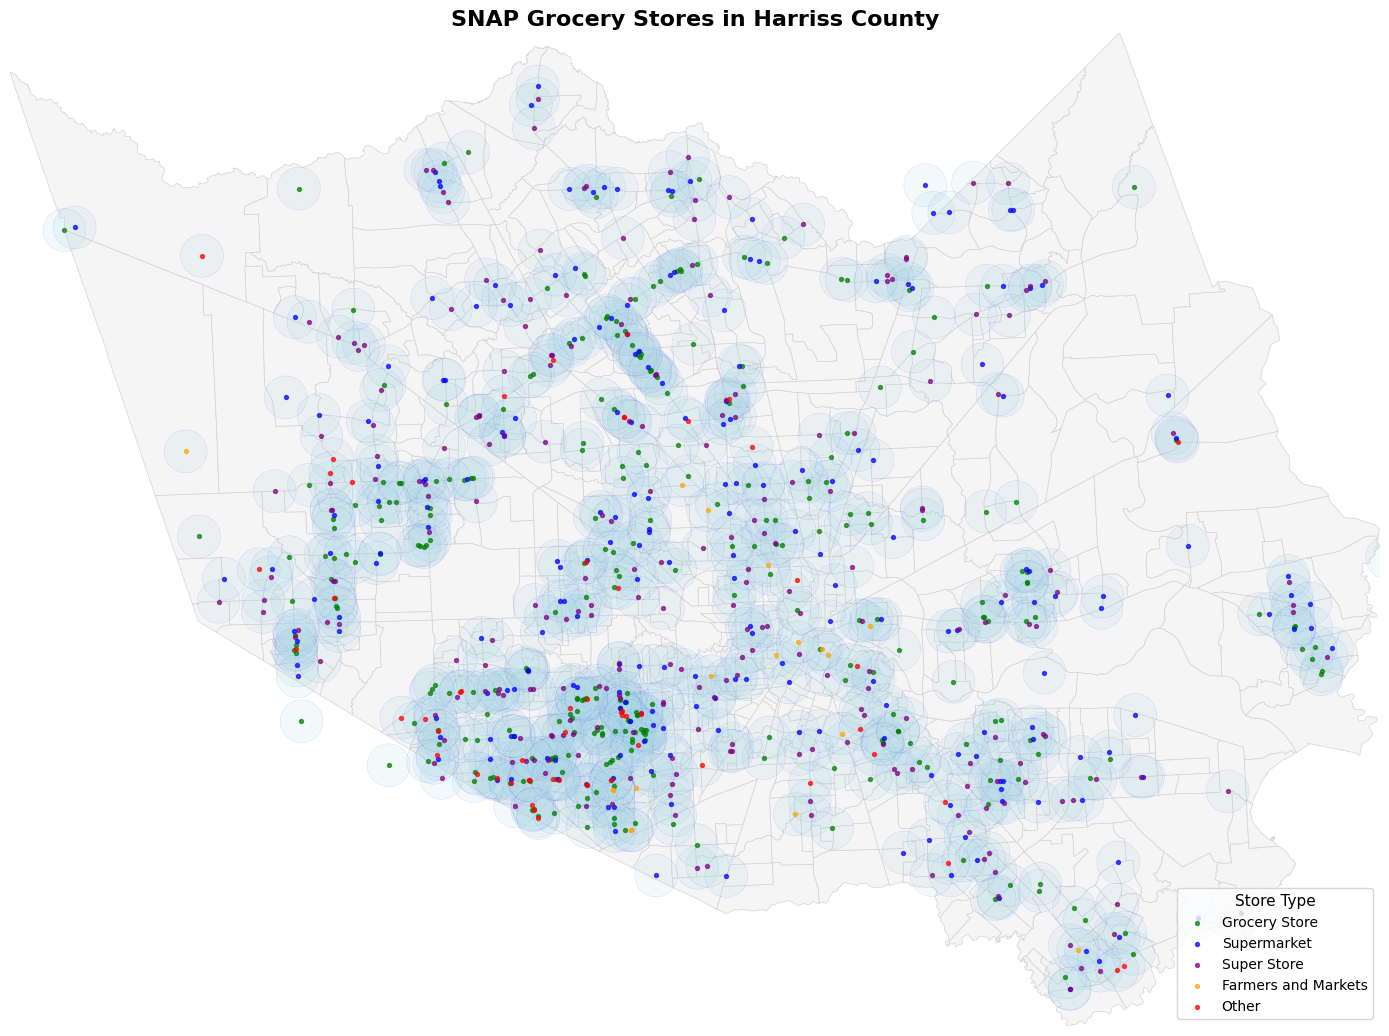

In [7]:
# convert to the right coordinate format
geo_df_projected = geo_df.to_crs(epsg=32614)
harris_projected = harris.to_crs(epsg=32614)

# create buffers
geo_df_buffer = geo_df_projected.copy()
geo_df_buffer["geometry"] = geo_df_projected.geometry.buffer(1609)

colors = {
    "Grocery Store": "green",
    "Supermarket": "blue",
    "Super Store": "purple",
    "Farmers and Markets": "orange",
    "Other": "red"
}

fig, ax = plt.subplots(figsize=(14, 12))

# project both graphs
harris_projected.plot(ax=ax, color="whitesmoke", edgecolor="lightgrey", linewidth=0.5)
geo_df_buffer.plot(ax=ax, color="lightblue", alpha=0.15, edgecolor="blue", linewidth=0.3)

for store_type, color in colors.items():
    subset = geo_df_projected[geo_df_projected["Store_Type"] == store_type]
    subset.plot(ax=ax, marker='o', color=color, markersize=8, alpha=0.7, label=store_type)

# legend 
ax.set_xlim(harris_projected.total_bounds[[0, 2]])
ax.set_ylim(harris_projected.total_bounds[[1, 3]])

ax.legend(title="Store Type", fontsize=10, title_fontsize=11, loc="lower right")
ax.axis("off")
ax.set_title("SNAP Grocery Stores in Harriss County", fontsize=16, fontweight="bold", pad=5)
plt.tight_layout()
plt.show()

In [8]:
# adding OpenStreetMap
shp_path = "../OpenStreetMap/gis_osm_roads_free_1.shp"
roads = GeoDataFrame.from_file(shp_path, encoding='utf-8')
roads.head()

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,geometry
0,4342988,5111,motorway,Sam Rayburn Tollway,SRT,F,112,0,F,F,"LINESTRING (-97.00107 32.98973, -97.0021 32.99..."
1,4343083,5111,motorway,Sam Rayburn Tollway,SRT,F,112,0,F,F,"LINESTRING (-97.00623 32.99057, -97.00568 32.9..."
2,4343084,5111,motorway,Sam Rayburn Tollway,SRT,F,112,1,T,F,"LINESTRING (-96.99295 32.98645, -96.99329 32.9..."
3,4343087,5131,motorway_link,None,None,F,0,0,F,F,"LINESTRING (-96.99882 32.98826, -96.9981 32.98..."
4,4343088,5131,motorway_link,None,None,F,0,0,F,F,"LINESTRING (-96.99669 32.98806, -96.99731 32.9..."


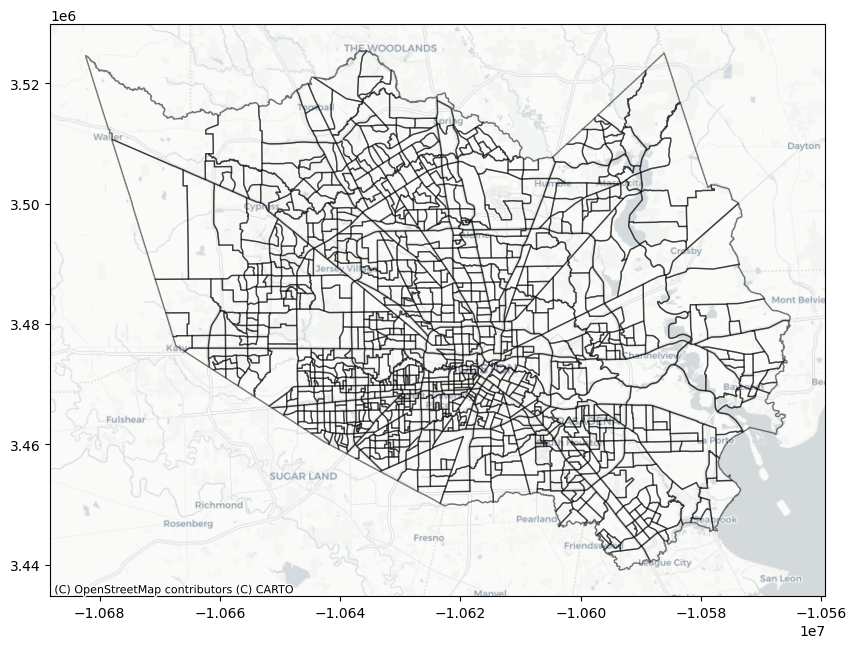

In [9]:
# testing 
ax = harris_wm.plot(figsize=(10, 10), alpha=0.5, edgecolor="k", facecolor="none")
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

<Figure size 640x480 with 0 Axes>

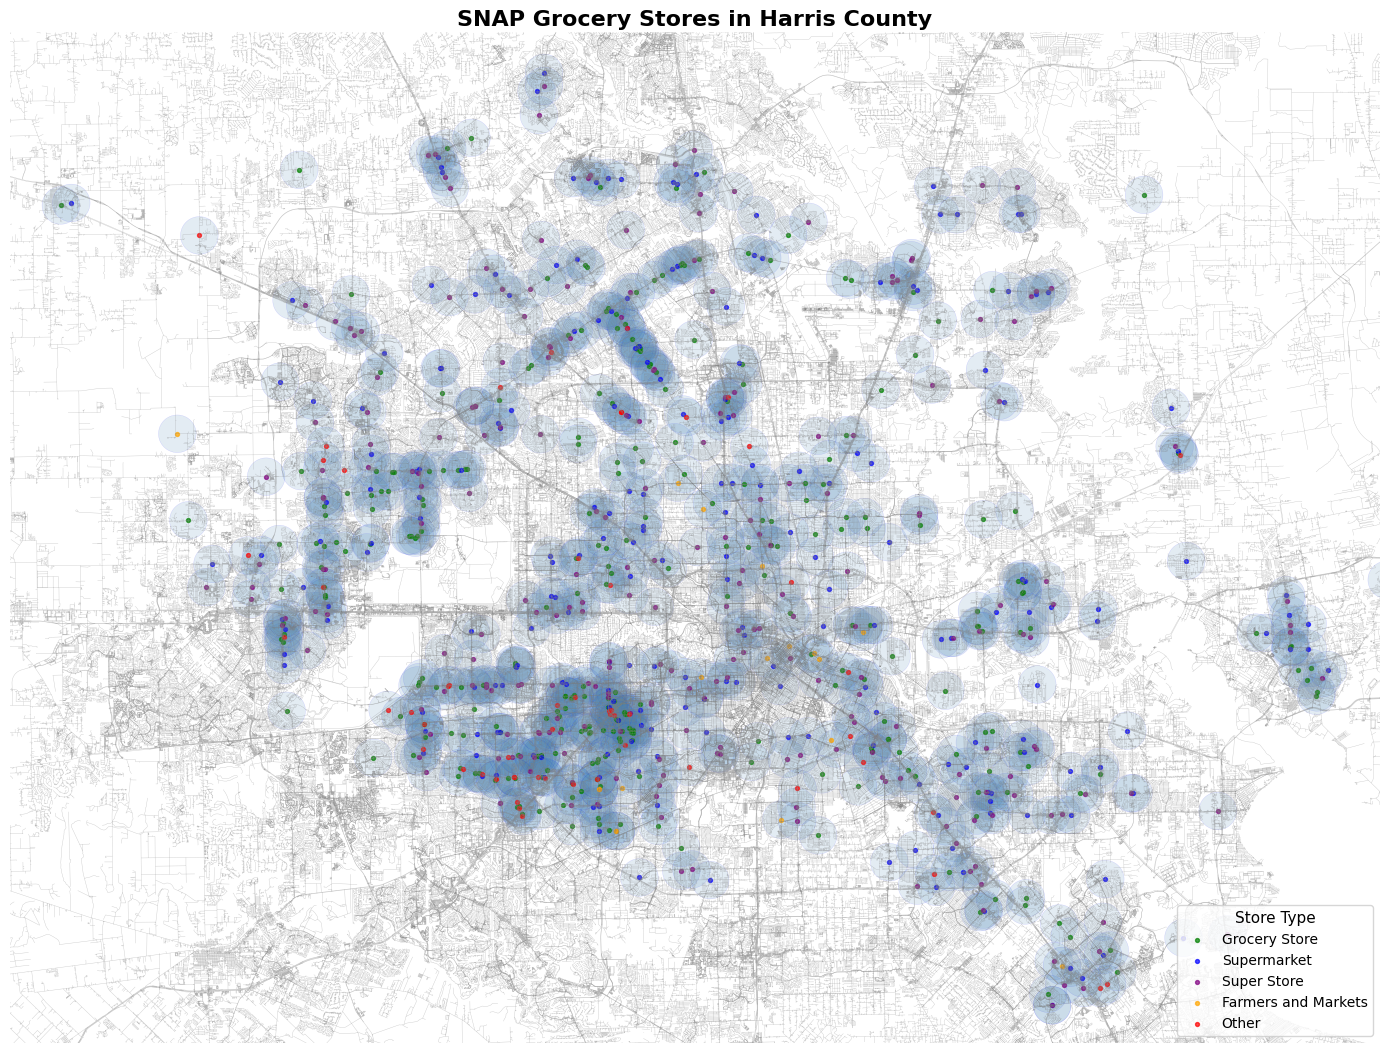

In [10]:
geo_df_buffer_wm = geo_df_wm.copy()

geo_df_buffer_wm["geometry"] = geo_df_wm.geometry.buffer(1609)
roads_wm = roads.clip(harris.total_bounds).to_crs(epsg=3857)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zorder=0)

colors = {
    "Grocery Store": "green",
    "Supermarket": "blue",
    "Super Store": "purple",
    "Farmers and Markets": "orange",
    "Other": "red"
}

fig, ax = plt.subplots(figsize=(14, 12))

roads_wm.plot(ax=ax, color="gray", linewidth=0.3, alpha=0.4)
geo_df_buffer_wm.plot(ax=ax, color="steelblue", alpha=0.15, edgecolor="blue", linewidth=0.3)

for store_type, color in colors.items():
    subset = geo_df_wm[geo_df_wm["Store_Type"] == store_type]
    subset.plot(ax=ax, marker='o', color=color, markersize=8, alpha=0.7, label=store_type)
    
ax.set_xlim(harris_wm.total_bounds[[0, 2]])
ax.set_ylim(harris_wm.total_bounds[[1, 3]])

ax.legend(title="Store Type", fontsize=10, title_fontsize=11, loc="lower right")
ax.axis("off")
ax.set_title("SNAP Grocery Stores in Harris County", fontsize=16, fontweight="bold", pad=5)
plt.tight_layout()

plt.savefig("harris_snap_map.png", dpi=300, bbox_inches="tight")
plt.show()